<h1 style="font-family: Georgia, serif; color: #1a252f; font-size: 2em; border-bottom: 3px solid #2980b9; padding-bottom: 10px; margin-bottom: 6px;">
  Notebook 01 &mdash; Exploração do Corpus
</h1>
<p style="font-family: Georgia, serif; color: #666; font-size: 1.05em; margin-top: 4px; margin-bottom: 22px;">
  Dissertações de Mestrado em Engenharia Elétrica e de Computação &mdash; UFRN
</p>

<div style="background: #f4f8fb; border-left: 4px solid #2980b9; padding: 12px 16px; border-radius: 3px; font-family: sans-serif; font-size: 0.92em; color: #333; line-height: 1.65;">
  <strong>Objetivo:</strong> conhecer o corpus antes de qualquer processamento.
  Este notebook carrega os metadados das 13 dissertações coletadas, extrai o texto bruto
  dos PDFs com <code>pymupdf</code> e computa estatísticas descritivas sobre tamanho,
  volume textual e composição do corpus. Nenhum resultado aqui depende do NER ou dos grafos.
</div>

<br>

<table style="font-family: sans-serif; font-size: 0.88em; color: #444; border-collapse: collapse;">
  <tr><td style="padding: 3px 16px 3px 0; color: #888;">Corpus</td><td>13 dissertações de mestrado</td></tr>
  <tr><td style="padding: 3px 16px 3px 0; color: #888;">Programa</td><td>Mestrado em Engenharia Elétrica / Engenharia Elétrica e de Computação</td></tr>
  <tr><td style="padding: 3px 16px 3px 0; color: #888;">Instituição</td><td>Universidade Federal do Rio Grande do Norte (UFRN)</td></tr>
  <tr><td style="padding: 3px 16px 3px 0; color: #888;">Período</td><td>2014 – 2024</td></tr>
  <tr><td style="padding: 3px 16px 3px 0; color: #888;">Extração de PDF</td><td>pymupdf</td></tr>
</table>

<h2 style="font-family: Georgia, serif; color: #2c3e50; border-bottom: 1px solid #dce0e4; padding-bottom: 6px; margin-top: 30px;">
  1. Configuração
</h2>
<p style="font-family: sans-serif; font-size: 0.9em; color: #555; line-height: 1.65; max-width: 820px;">
  Importações, definição de caminhos e configuração global dos gráficos.
  Todos os caminhos são relativos ao diretório <code>notebooks/</code>, onde este arquivo reside.
  Os diretórios de saída são criados automaticamente caso não existam.
</p>

In [55]:
import re
import json
import warnings
from pathlib import Path

import pandas as pd
import fitz  # PyMuPDF
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

warnings.filterwarnings("ignore")

In [56]:
# ── Caminhos do projeto ──────────────────────────────────────────────────────
ROOT        = Path("..")          # raiz do projeto (um nível acima de notebooks/)
DIR_META    = ROOT / "metadados_teses"
DIR_TESES   = ROOT / "teses"
DIR_TEXT    = ROOT / "data" / "extracted_text"
DIR_FIGURES = ROOT / "figures" / "01_corpus_exploration"
DIR_RESULTS = ROOT / "results" / "01_corpus_exploration"

for d in [DIR_TEXT, DIR_FIGURES, DIR_RESULTS]:
    d.mkdir(parents=True, exist_ok=True)

print("Verificação de diretórios:")
for label, d in [("metadados_teses", DIR_META),
                  ("teses           ", DIR_TESES),
                  ("data/extracted_text", DIR_TEXT),
                  ("figures/01_corpus_exploration", DIR_FIGURES),
                  ("results/01_corpus_exploration", DIR_RESULTS)]:
    status = "ok" if d.exists() else "NAO ENCONTRADO"
    print(f"  {label:22s}  {status}")

Verificação de diretórios:
  metadados_teses         ok
  teses                   ok
  data/extracted_text     ok
  figures/01_corpus_exploration  ok
  results/01_corpus_exploration  ok


In [57]:
# ── Estilo global dos gráficos ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f9f9f9",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e2e2e2",
    "grid.linestyle":    "--",
    "grid.linewidth":    0.6,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
})

# Paleta de cores consistente em todo o notebook
COR_AZUL    = "#2980b9"
COR_LARANJA = "#e67e22"
COR_VERDE   = "#27ae60"
COR_ROXO    = "#8e44ad"
PALETA      = [COR_AZUL, COR_LARANJA, COR_VERDE, COR_ROXO,
               "#c0392b", "#16a085", "#d35400", "#2c3e50"]

print("Estilo aplicado.")

Estilo aplicado.


<h2 style="font-family: Georgia, serif; color: #2c3e50; border-bottom: 1px solid #dce0e4; padding-bottom: 6px; margin-top: 30px;">
  2. Carregamento dos Metadados
</h2>
<p style="font-family: sans-serif; font-size: 0.9em; color: #555; line-height: 1.65; max-width: 820px;">
  Cada dissertação possui um arquivo CSV individual em <code>metadados_teses/</code>.
  Os arquivos são concatenados em um único DataFrame, que será a base de todas as análises.
  O campo <code>tese_id</code> é extraído do prefixo numérico do nome do arquivo CSV
  (ex.: <code>01</code> de <code>01_mateus_...csv</code>) e utilizado como chave para
  relacionar metadados, PDFs e textos extraídos.
</p>

In [58]:
def load_metadata(meta_dir: Path) -> pd.DataFrame:
    """Carrega e concatena todos os CSVs de metadados.

    Parâmetros
    ----------
    meta_dir : Path
        Diretório que contém os CSVs individuais.

    Retorna
    -------
    pd.DataFrame com coluna 'tese_id' adicionada ao início.
    """
    frames = []
    for csv_path in sorted(meta_dir.glob("*.csv")):
        tese_id = csv_path.stem.split("_")[0]   # prefixo numérico
        df_tmp  = pd.read_csv(csv_path, encoding="utf-8-sig")
        df_tmp.insert(0, "tese_id", tese_id)
        frames.append(df_tmp)
    return pd.concat(frames, ignore_index=True)


meta = load_metadata(DIR_META)

# Normaliza nomes de colunas: lowercase, sem espaços, sem acentos básicos
meta.columns = (
    meta.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("ã", "a", regex=False)
    .str.replace("ç", "c", regex=False)
    .str.replace("é", "e", regex=False)
    .str.replace("ó", "o", regex=False)
)

meta["ano"] = pd.to_numeric(meta["ano"], errors="coerce").astype("Int64")

print(f"Dissertações carregadas : {len(meta)}")
print(f"Colunas disponíveis     : {list(meta.columns)}")

Dissertações carregadas : 13
Colunas disponíveis     : ['tese_id', 'autor', 'titulo', 'ano', 'tipo', 'grau_secao', 'programa', 'instituicao', 'agencia', 'orientador_ou_coorientador', 'status_fonte', 'link_pdf_ou_item', 'observacao']


In [59]:
# Exibe as colunas mais relevantes para inspeção
colunas_exibir = ["tese_id", "autor", "titulo", "ano", "programa", "agencia"]
colunas_exibir = [c for c in colunas_exibir if c in meta.columns]

pd.set_option("display.max_colwidth", 68)
meta[colunas_exibir]

,tese_id,autor,titulo,ano,programa,agencia
0,01,MATEUS ARNAUD SANTOS DE SOUSA GOLDBARG,Compressão Consciente de Modelos de Redes Neurais Profundas Base...,2024,Mestrado em Engenharia Elétrica,Conselho Nacional de Desenvolvimento Científico e Tecnológico
1,03,LUISA CHRISTINA DE SOUZA,Nova proposta de representação de genoma viral aplicada na class...,2022,Mestrado em Engenharia Elétrica,Coordenação de Aperfeiçoamento de Pessoal de Nível Superior
2,05,KAROLAYNE SANTOS DE AZEVEDO,Aprendizagem profunda aplicada à classificação e avaliação do co...,2022,Mestrado em Engenharia Elétrica,Coordenação de Aperfeiçoamento de Pessoal de Nível Superior
3,09,EMANOEL LUCAS RODRIGUES COSTA,Aprendizagem de máquina aplicada ao agrupamento de dados ambientais,2020,Mestrado em Engenharia Elétrica,Coordenação de Aperfeiçoamento de Pessoal de Nível Superior
4,11,MARIA GRACIELLY FERNANDES COUTINHO,Reconfigurable Computing applied to the Deep Learning Algorithms,2018,Mestrado em Engenharia Elétrica,Coordenação de Aperfeiçoamento de Pessoal de Nível Superior
5,12,Matheus Fernandes Torquato,Proposta de implementação paralela de algoritmo genético em FPGA,2017,Mestrado em Engenharia Elétrica e de Computação,Coordenação de Aperfeiçoamento de Pessoal de Nível Superior
6,13,Daniel Holanda Noronha,Proposta de Implementação em FPGA de Máquina de Vetores de Suporte,2017,Mestrado em Engenharia Elétrica e de Computação,NaN
7,14,Sérgio Natan Silva,Simulador de Tempo Real para Sistemas Dinâmicos Em FPGA,2016,Mestrado em Engenharia Elétrica e de Computação,Coordenação de Aperfeiçoamento de Pessoal de Nível Superior
8,15,Caroline Albuquerque Dantas Silva,Proposta de equalizador cego baseado em algoritmos genéticos,2016,Mestrado em Engenharia Elétrica e de Computação,Coordenação de Aperfeiçoamento de Pessoal de Nível Superior
9,16,Lucileide Medeiros Dantas da Silva,Proposta de arquitetura em Hardware para FPGA da técnica Qlearni...,2016,Mestrado em Engenharia Elétrica e de Computação,NaN


In [60]:
# ── Verifica se o PDF existe para cada entrada de metadado ───────────────────
def find_pdf(tese_id: str, teses_dir: Path) -> Path | None:
    """Localiza o PDF correspondente ao tese_id pelo padrão 'mestrado_<id>_*.pdf'."""
    matches = list(teses_dir.glob(f"mestrado_{tese_id}_*.pdf"))
    return matches[0] if matches else None


meta["pdf_path"]  = meta["tese_id"].apply(lambda tid: find_pdf(tid, DIR_TESES))
meta["pdf_found"] = meta["pdf_path"].notna()

n_found = meta["pdf_found"].sum()
print(f"PDFs localizados: {n_found} / {len(meta)}")

ausentes = meta.loc[~meta["pdf_found"], ["tese_id", "autor"]]
if not ausentes.empty:
    print("\nPDFs nao encontrados:")
    print(ausentes.to_string(index=False))
else:
    print("Todos os PDFs foram localizados.")

PDFs localizados: 13 / 13
Todos os PDFs foram localizados.


<h2 style="font-family: Georgia, serif; color: #2c3e50; border-bottom: 1px solid #dce0e4; padding-bottom: 6px; margin-top: 30px;">
  3. Composição e Distribuição do Corpus
</h2>
<p style="font-family: sans-serif; font-size: 0.9em; color: #555; line-height: 1.65; max-width: 820px;">
  Distribuição por ano de defesa, programa e agência de fomento.
  Como todo o corpus pertence à mesma instituição (UFRN) e ao mesmo orientador
  (Prof. Marcelo Fernandes), as variações mais informativas são o recorte temporal
  e a nomenclatura do programa ao longo dos anos.
</p>

In [61]:
# ── Prepara os campos para os gráficos ──────────────────────────────────────

# Abreviações de programa
prog_abrev = {
    "Mestrado em Engenharia Elétrica":                 "MEE",
    "Mestrado em Engenharia Elétrica e de Computação": "MEEC",
}
meta["programa_abrev"] = meta["programa"].map(lambda x: prog_abrev.get(x, x))

# Abreviações de agência
agencia_abrev = {
    "Conselho Nacional de Desenvolvimento Científico e Tecnológico": "CNPq",
    "Coordenação de Aperfeiçoamento de Pessoal de Nível Superior":   "CAPES",
}
col_ag = "agencia" if "agencia" in meta.columns else None
if col_ag:
    meta["agencia_abrev"] = (
        meta[col_ag].fillna("Não informado").str.strip()
        .replace("", "Não informado")
        .map(lambda x: agencia_abrev.get(x, x))
    )

print("Campos preparados.")

Campos preparados.


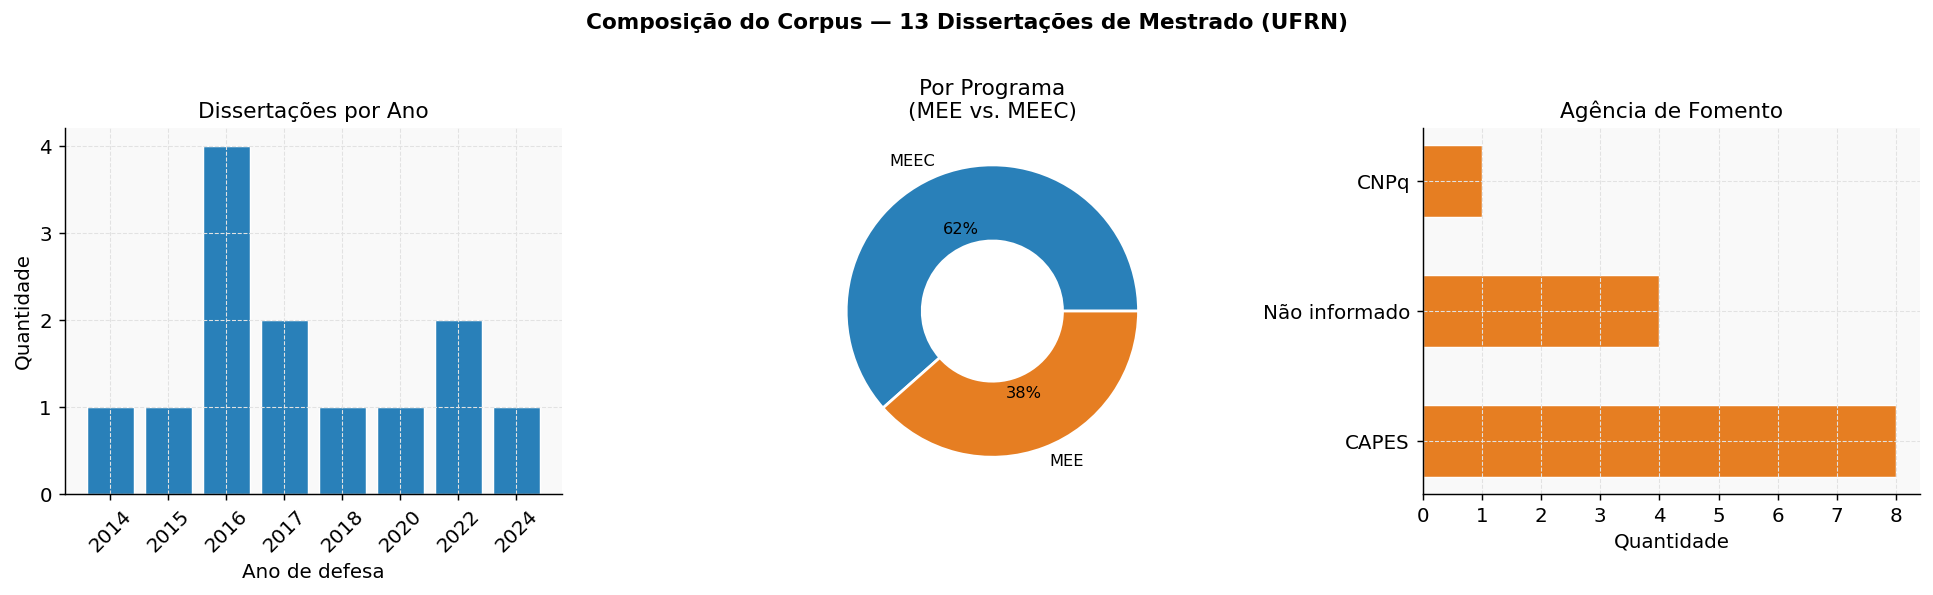

Figura salva: ../figures/01_corpus_exploration/01_composicao_corpus.png


In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Composição do Corpus — 13 Dissertações de Mestrado (UFRN)",
             fontsize=12, fontweight="bold", y=1.01)

# ── Painel 1: distribuição por ano ──────────────────────────────────────────
ano_counts = meta["ano"].value_counts().sort_index()
axes[0].bar(
    ano_counts.index.astype(str), ano_counts.values,
    color=COR_AZUL, edgecolor="white", linewidth=0.8
)
axes[0].set_title("Dissertações por Ano")
axes[0].set_xlabel("Ano de defesa")
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis="x", rotation=45)
axes[0].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# ── Painel 2: distribuição por programa ─────────────────────────────────────
prog_counts = meta["programa_abrev"].value_counts()
wedge_props = dict(width=0.52, edgecolor="white", linewidth=1.5)
axes[1].pie(
    prog_counts.values,
    labels=prog_counts.index,
    autopct="%1.0f%%",
    colors=PALETA[:len(prog_counts)],
    wedgeprops=wedge_props,
    textprops={"fontsize": 9}
)
axes[1].set_title("Por Programa\n(MEE vs. MEEC)")

# ── Painel 3: agência de fomento ─────────────────────────────────────────────
if col_ag:
    ag_counts = meta["agencia_abrev"].value_counts()
    axes[2].barh(
        ag_counts.index, ag_counts.values,
        color=COR_LARANJA, edgecolor="white", linewidth=0.8, height=0.55
    )
    axes[2].set_title("Agência de Fomento")
    axes[2].set_xlabel("Quantidade")
    axes[2].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
else:
    axes[2].axis("off")

plt.tight_layout()
fig_path = DIR_FIGURES / "01_composicao_corpus.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

In [63]:
# ── Linha do tempo textual ───────────────────────────────────────────────────
print("Linha do tempo do corpus (ordem cronológica):\n")
print(f"  {'Ano':>4}  {'Sobrenome':18}  {'Título (65 chars)'}")
print("  " + "-" * 88)
for _, row in meta.sort_values("ano").iterrows():
    sobrenome = row["autor"].split()[-1].title()
    titulo_c  = row["titulo"][:65] + ("..." if len(row["titulo"]) > 65 else "")
    print(f"  {str(row['ano']):>4}  {sobrenome:18}  {titulo_c}")

Linha do tempo do corpus (ordem cronológica):

   Ano  Sobrenome           Título (65 chars)
  ----------------------------------------------------------------------------------------
  2014  Sousa               Equalização Neural Aplicada a Sistemas com Modulação Bidimensiona...
  2015  Oliveira            Estratégia de navegação com planejamento dinâmico e algoritmo gen...
  2016  Silva               Simulador de Tempo Real para Sistemas Dinâmicos Em FPGA
  2016  Silva               Proposta de equalizador cego baseado em algoritmos genéticos
  2016  Silva               Proposta de arquitetura em Hardware para FPGA da técnica Qlearnin...
  2016  Júnior              Proposta de Implementação dos Algoritmos MD5 e SHA-1 em Hardware
  2017  Torquato            Proposta de implementação paralela de algoritmo genético em FPGA
  2017  Noronha             Proposta de Implementação em FPGA de Máquina de Vetores de Suport...
  2018  Coutinho            Reconfigurable Computing applied to the D

<h2 style="font-family: Georgia, serif; color: #2c3e50; border-bottom: 1px solid #dce0e4; padding-bottom: 6px; margin-top: 30px;">
  4. Volume de Páginas por Dissertação
</h2>
<p style="font-family: sans-serif; font-size: 0.9em; color: #555; line-height: 1.65; max-width: 820px;">
  A contagem de páginas é extraída diretamente via <code>pymupdf</code>, sem processar o texto.
  O objetivo é detectar PDFs atipicamente curtos ou longos, que podem indicar arquivos
  incompletos, com muitas páginas em branco ou com conteúdo predominantemente visual
  (figuras, tabelas, equações).
</p>

In [64]:
def count_pages(pdf_path: Path) -> int:
    """Retorna o número de páginas do PDF. Retorna 0 em caso de erro."""
    try:
        doc = fitz.open(str(pdf_path))
        n = len(doc)
        doc.close()
        return n
    except Exception:
        return 0


meta["n_paginas"] = meta["pdf_path"].apply(
    lambda p: count_pages(p) if p is not None else 0
)

print("Resumo — número de páginas por dissertação:")
print(meta["n_paginas"].describe().round(1).rename({
    "count": "N", "mean": "média", "std": "desvio",
    "min": "mín", "max": "máx"
}).to_string())


Resumo — número de páginas por dissertação:
N         13.0
média      0.0
desvio     0.0
mín        0.0
25%        0.0
50%        0.0
75%        0.0
máx        0.0


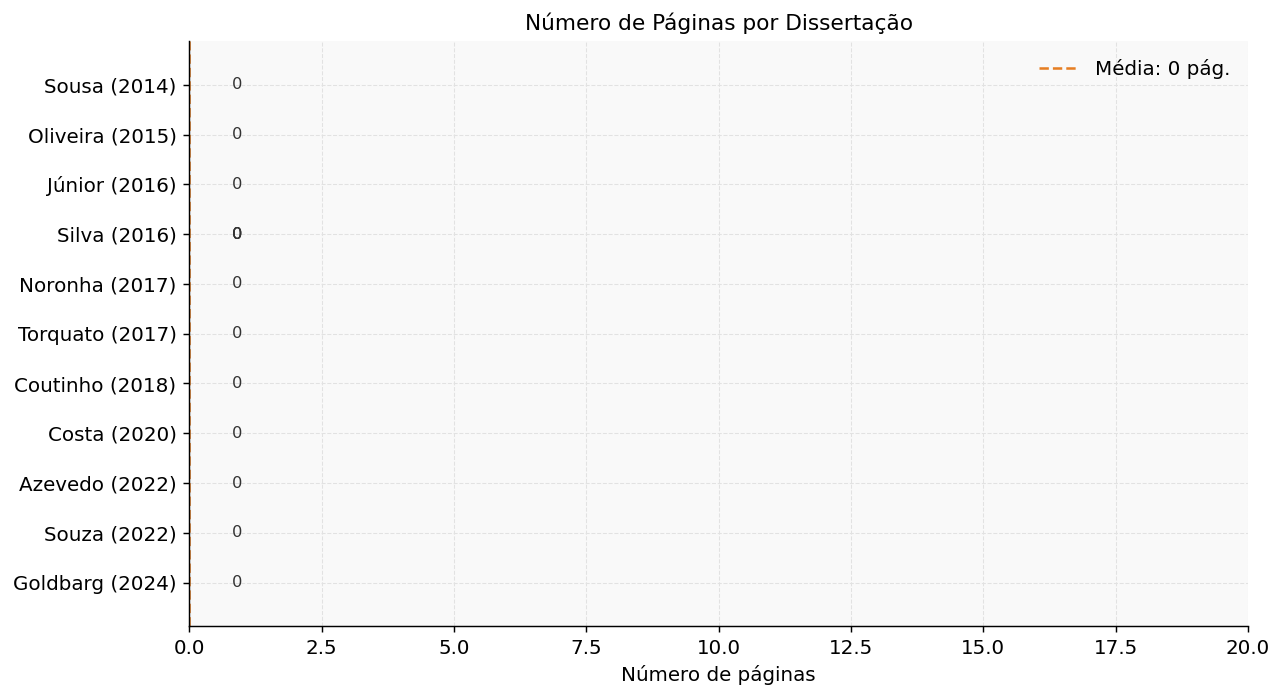

Figura salva: ../figures/01_corpus_exploration/02_paginas_por_dissertacao.png


In [65]:
df_pag = (
    meta[["tese_id", "autor", "ano", "n_paginas"]]
    .dropna(subset=["n_paginas"])
    .copy()
)
df_pag["label"] = df_pag.apply(
    lambda r: f"{r['autor'].split()[-1].title()} ({r['ano']})", axis=1
)
df_pag = df_pag.sort_values("n_paginas")

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    df_pag["label"], df_pag["n_paginas"],
    color=COR_AZUL, edgecolor="white", linewidth=0.7, height=0.68
)

media_p = df_pag["n_paginas"].mean()
ax.axvline(media_p, color=COR_LARANJA, linestyle="--", linewidth=1.4,
           label=f"Média: {media_p:.0f} pág.")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.8, bar.get_y() + bar.get_height() / 2,
            str(int(w)), va="center", fontsize=9, color="#333")

ax.set_title("Número de Páginas por Dissertação")
ax.set_xlabel("Número de páginas")
ax.set_xlim(0, df_pag["n_paginas"].max() + 20)
ax.legend(frameon=False)

plt.tight_layout()
fig_path = DIR_FIGURES / "02_paginas_por_dissertacao.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

<h2 style="font-family: Georgia, serif; color: #2c3e50; border-bottom: 1px solid #dce0e4; padding-bottom: 6px; margin-top: 30px;">
  5. Extração de Texto e Volume de Conteúdo
</h2>
<p style="font-family: sans-serif; font-size: 0.9em; color: #555; line-height: 1.65; max-width: 820px;">
  O texto de cada PDF é extraído com <code>pymupdf</code>, aplicando limpeza mínima:
  correção de hifenização no final de linha, descarte de linhas com menos de 20 caracteres
  (números de página isolados, cabeçalhos muito curtos) e normalização de espaços em branco.
  O texto e as linhas limpas são salvos em <code>data/extracted_text/&lt;id&gt;.json</code>.
  Re-execuções do notebook reutilizam arquivos já existentes, sem reprocessar.
</p>
<div style="background: #fffbf0; border-left: 4px solid #e67e22; padding: 10px 14px; border-radius: 3px; font-family: sans-serif; font-size: 0.88em; color: #444; line-height: 1.6; margin-top: 10px;">
  <strong>Limitação conhecida:</strong>
  PDFs acadêmicos brasileiros frequentemente apresentam palavras concatenadas sem espaço
  (artefato de compressão ou de OCR). Isso afeta a contagem de tokens e a segmentação de
  sentenças. O diagnóstico desta limitação é feito na Seção 6.
</div>

In [66]:
import unicodedata

# ── Funções de limpeza de texto ───────────────────────────────────────────────

def normalize_ligatures(text: str) -> str:
    """Converte ligaduras tipográficas (ﬁ→fi, ﬂ→fl, ﬀ→ff, etc.)."""
    return unicodedata.normalize("NFKC", text)

SECTIONS_TO_SKIP = [
    "agradec", "dedicat", "abstract", "keywords",
    "lista de siglas", "lista de abreviaturas",
]

def is_irrelevant_section(page_text: str) -> bool:
    """Retorna True se a página parecer ser uma seção irrelevante para NER."""
    first_line = page_text.strip().split("\n")[0].lower()
    return any(kw in first_line for kw in SECTIONS_TO_SKIP)

def remove_front_matter(pages: list) -> list:
    """Descarta páginas de sumário, lista de figuras/tabelas, etc."""
    skip_patterns = [
        r"^Sumário", r"^Lista de Figuras", r"^Lista de Tabelas",
        r"^Lista de Siglas", r"^Abstract\b",
    ]
    pattern = re.compile("|".join(skip_patterns), re.IGNORECASE)
    return [p for p in pages if not pattern.match(p.strip())]

def remove_references_section(pages: list) -> list:
    """Remove as páginas de referências bibliográficas."""
    in_refs = False
    clean = []
    for page in pages:
        if re.match(r"^(Referências|References|Bibliografia)", page.strip(), re.I):
            in_refs = True
        if not in_refs:
            clean.append(page)
    return clean

print("Funções de limpeza de texto definidas.")


Funções de limpeza de texto definidas.


In [67]:
def extract_text(pdf_path: Path) -> dict:
    """Extrai e limpa o texto de um PDF com PyMuPDF (fitz).

    Passos aplicados por página:
      1. Extração do texto via fitz (PyMuPDF).
      2. Correção de hifenização intra-linha: 'aprendi-\\nzagem' → 'aprendizagem'.
      3. Remoção de linhas com menos de 20 caracteres.

    Retorna
    -------
    dict com:
      - 'pages': list[str] — texto por página (pós-limpeza).
      - 'lines': list[str] — todas as linhas com >= 20 chars do documento.
    """
    pages_text = []
    doc = fitz.open(str(pdf_path))
    for page in doc:
        raw = page.get_text()
        if not raw:
            continue
        # Corrige hifenização de quebra de linha
        cleaned = re.sub(r"(\w)-\n(\w)", r"\1\2", raw)
        pages_text.append(cleaned.strip())
    doc.close()

    full_text = "\n".join(pages_text)

    lines = [
        ln.strip()
        for ln in full_text.splitlines()
        if len(ln.strip()) >= 20
    ]

    return {"pages": pages_text, "lines": lines}


print("Função extract_text definida.")


Função extract_text definida.


In [68]:
def chunk_text(text: str, max_tokens: int = 400, overlap: int = 50) -> list:
    """
    Divide o texto em chunks por sentenças respeitando o limite de tokens.
    O overlap evita perder entidades no corte entre chunks.
    """
    sentences = re.split(r"(?<=[.!?])\s+", text)
    chunks, current, current_len = [], [], 0

    for sent in sentences:
        sent_len = len(sent.split())
        if current_len + sent_len > max_tokens and current:
            chunks.append(" ".join(current))
            overlap_text = " ".join(" ".join(current).split()[-overlap:])
            current = [overlap_text, sent]
            current_len = overlap + sent_len
        else:
            current.append(sent)
            current_len += sent_len

    if current:
        chunks.append(" ".join(current))
    return chunks


def build_ner_input(pdf_path) -> list:
    """
    Pipeline completo: extração → limpeza → segmentação → chunks prontos para NER.
    """
    raw_pages = extract_text(pdf_path)["pages"]

    pages = remove_front_matter(raw_pages)
    pages = remove_references_section(pages)
    pages = [p for p in pages if not is_irrelevant_section(p)]

    clean_pages = []
    for page in pages:
        page = normalize_ligatures(page)
        page = re.sub(r"\n\d+\nCAPÍTULO \d+\..*?\n", "\n", page)
        clean_pages.append(page)

    full_text = "\n".join(clean_pages)
    return chunk_text(full_text, max_tokens=400, overlap=50)

print("Pipeline NER (build_ner_input) definido.")


Pipeline NER (build_ner_input) definido.


In [69]:
text_stats = []
header = f"  {'ID':>3}  {'Sobrenome':20}  {'Pág c/ texto':>12}  {'Linhas':>8}  {'Palavras':>10}"
print(header)
print("  " + "-" * (len(header) - 2))

for _, row in meta.sort_values("tese_id").iterrows():
    if row["pdf_path"] is None:
        continue

    tese_id   = row["tese_id"]
    out_path  = DIR_TEXT / f"{tese_id}.json"
    sobrenome = row["autor"].split()[-1].title()

    # Reutiliza extração já salva
    if out_path.exists():
        with open(out_path, encoding="utf-8") as fh:
            data = json.load(fh)
    else:
        data = extract_text(row["pdf_path"])
        with open(out_path, "w", encoding="utf-8") as fh:
            json.dump(data, fh, ensure_ascii=False, indent=2)

    n_pag_txt = len(data["pages"])
    n_linhas  = len(data["lines"])
    n_palavras = sum(len(ln.split()) for ln in data["lines"])

    text_stats.append({
        "tese_id":     tese_id,
        "n_pag_texto": n_pag_txt,
        "n_linhas":    n_linhas,
        "n_palavras":  n_palavras,
    })
    print(f"  {tese_id:>3}  {sobrenome:20}  {n_pag_txt:>12}  {n_linhas:>8}  {n_palavras:>10,}")

df_text = pd.DataFrame(text_stats)
meta    = meta.merge(df_text, on="tese_id", how="left")

print(f"\nExtração concluída. Arquivos JSON salvos em: {DIR_TEXT}")

   ID  Sobrenome             Pág c/ texto    Linhas    Palavras
  -------------------------------------------------------------
   01  Goldbarg                        58      1050      14,576
   03  Souza                          131      2071      26,371
   05  Azevedo                         96      1914      26,110
   09  Costa                           90      1880      26,597
   11  Coutinho                        63      1233      16,331
   12  Torquato                        66      1229      16,592
   13  Noronha                         66      1229      16,592
   14  Silva                           75      1202      15,764
   15  Silva                           81      1457      19,435
   16  Silva                           65      1039      14,436
   17  Júnior                          66      1363      18,224
   18  Oliveira                        63       880       9,971
   19  Sousa                           80       993      13,274

Extração concluída. Arquivos JSON salvo

In [70]:
print("Resumo estatístico — volume textual por dissertação:\n")
resumo = (
    meta[["n_pag_texto", "n_linhas", "n_palavras"]]
    .describe()
    .round(1)
    .rename(index={"count": "N", "mean": "média", "std": "desvio",
                   "min": "mín", "max": "máx"})
)
print(resumo.to_string())

Resumo estatístico — volume textual por dissertação:

        n_pag_texto  n_linhas  n_palavras
N              13.0      13.0        13.0
média          76.9    1349.2     18021.0
desvio         19.9     379.7      5282.3
mín            58.0     880.0      9971.0
25%            65.0    1050.0     14576.0
50%            66.0    1229.0     16592.0
75%            81.0    1457.0     19435.0
máx           131.0    2071.0     26597.0


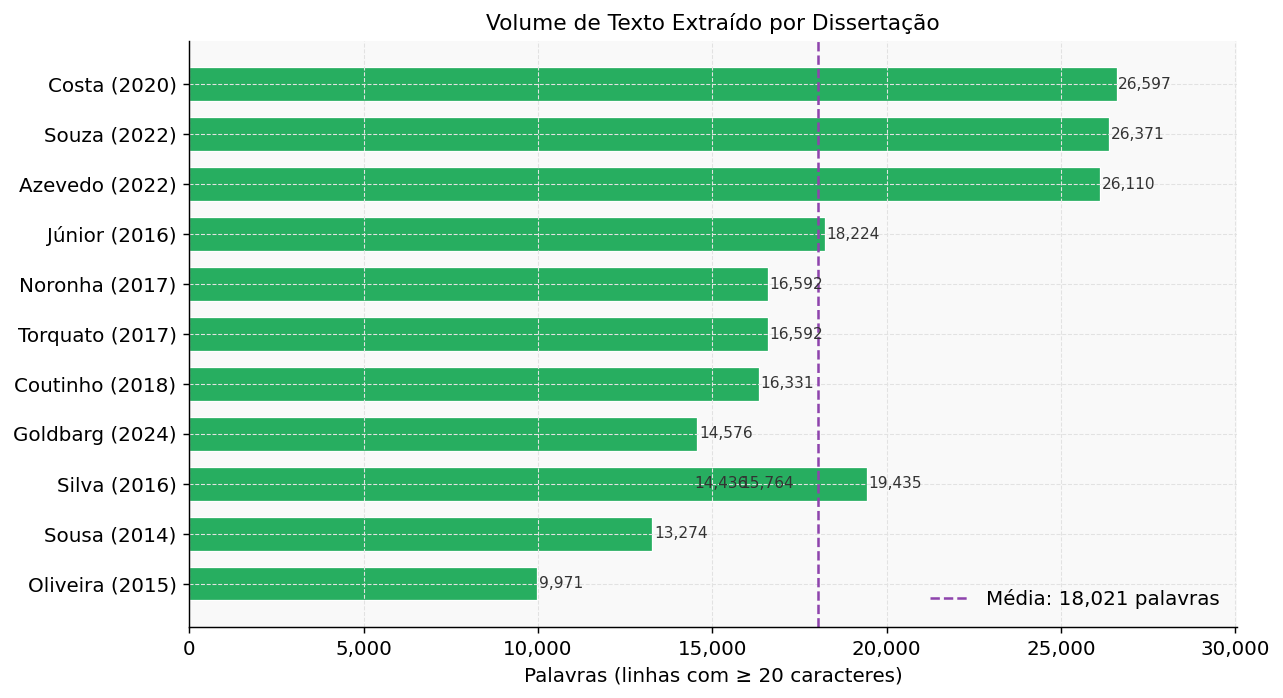

Figura salva: ../figures/01_corpus_exploration/03_palavras_por_dissertacao.png


In [71]:
# ── Palavras por dissertação (barras horizontais) ────────────────────────────
df_w = (
    meta[["tese_id", "autor", "ano", "n_palavras"]]
    .dropna(subset=["n_palavras"])
    .sort_values("n_palavras")
    .copy()
)
df_w["label"] = df_w.apply(
    lambda r: f"{r['autor'].split()[-1].title()} ({r['ano']})", axis=1
)

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    df_w["label"], df_w["n_palavras"],
    color=COR_VERDE, edgecolor="white", linewidth=0.7, height=0.68
)

media_w = df_w["n_palavras"].mean()
ax.axvline(media_w, color=COR_ROXO, linestyle="--", linewidth=1.4,
           label=f"Média: {media_w:,.0f} palavras")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 50, bar.get_y() + bar.get_height() / 2,
            f"{w:,.0f}", va="center", fontsize=8.5, color="#333")

ax.set_title("Volume de Texto Extraído por Dissertação")
ax.set_xlabel("Palavras (linhas com ≥ 20 caracteres)")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlim(0, df_w["n_palavras"].max() * 1.13)
ax.legend(frameon=False)

plt.tight_layout()
fig_path = DIR_FIGURES / "03_palavras_por_dissertacao.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

<h3 style="font-family: Georgia, serif; color: #34495e; margin-top: 22px;">
  Relação entre páginas e volume textual
</h3>
<p style="font-family: sans-serif; font-size: 0.9em; color: #555; line-height: 1.65; max-width: 820px;">
  Em dissertações com alta densidade de figuras, equações ou pseudocódigos, o número de
  palavras por página tende a ser baixo, mesmo em documentos extensos.
  Pontos abaixo da tendência linear indicam esses casos &mdash; que merecem verificação
  qualitativa antes do NER.
</p>

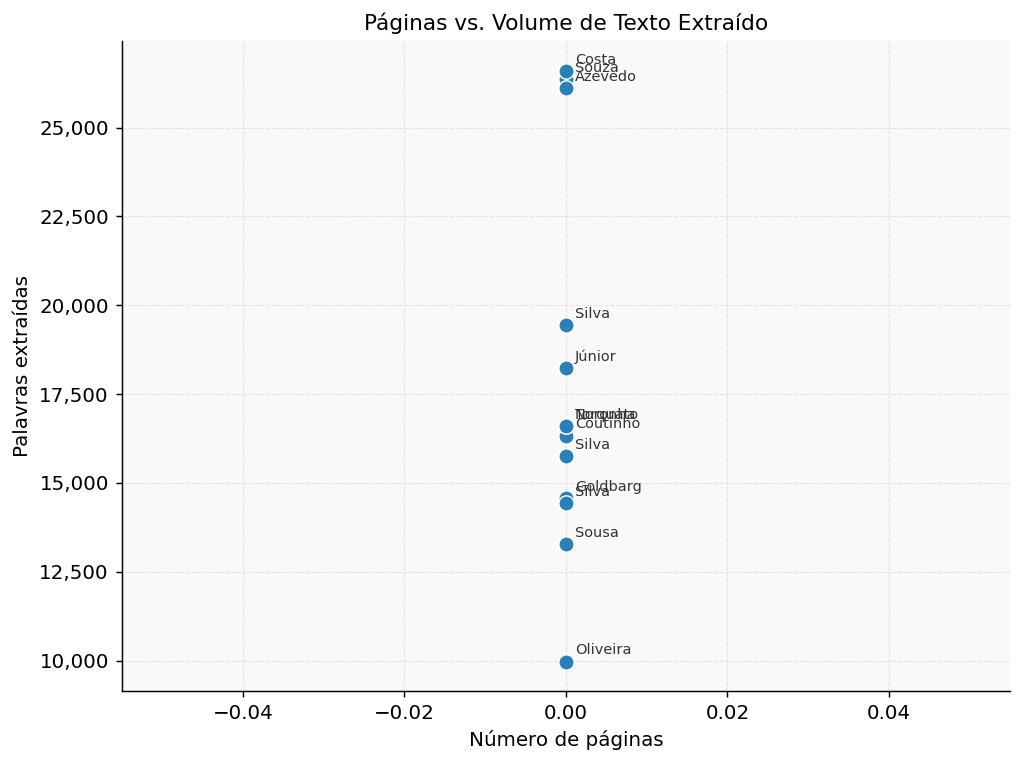

Figura salva: ../figures/01_corpus_exploration/04_scatter_paginas_palavras.png


In [74]:
df_sc = meta.copy()
df_sc["n_paginas"] = pd.to_numeric(df_sc["n_paginas"], errors="coerce")
df_sc["n_palavras"] = pd.to_numeric(df_sc["n_palavras"], errors="coerce")
df_sc = (
    df_sc.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["n_paginas", "n_palavras"])
    .copy()
)
df_sc["sobrenome"] = df_sc["autor"].apply(lambda x: x.split()[-1].title())
x = df_sc["n_paginas"].to_numpy(dtype=float)
y = df_sc["n_palavras"].to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    x, y,
    s=72, color=COR_AZUL, edgecolors="white", linewidths=0.8, zorder=3
)
if len(x) >= 2 and np.unique(x).size >= 2:
    coef = np.polyfit(x, y, deg=1)
    x_fit = np.linspace(x.min(), x.max(), 100)
    ax.plot(
        x_fit, np.polyval(coef, x_fit),
        color=COR_LARANJA, linestyle="--", linewidth=1.3,
        label="Tendência linear"
    )
for _, row in df_sc.iterrows():
    ax.annotate(
        row["sobrenome"],
        (row["n_paginas"], row["n_palavras"]),
        textcoords="offset points", xytext=(5, 4),
        fontsize=8, color="#333"
    )
ax.set_title("Páginas vs. Volume de Texto Extraído")
ax.set_xlabel("Número de páginas")
ax.set_ylabel("Palavras extraídas")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(frameon=False)
plt.tight_layout()
fig_path = DIR_FIGURES / "04_scatter_paginas_palavras.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

<h2 style="font-family: Georgia, serif; color: #2c3e50; border-bottom: 1px solid #dce0e4; padding-bottom: 6px; margin-top: 30px;">
  6. Verificação Qualitativa do Texto Extraído
</h2>
<p style="font-family: sans-serif; font-size: 0.9em; color: #555; line-height: 1.65; max-width: 820px;">
  Antes de avançar para o NER, é necessário confirmar que o texto extraído é legível.
  Duas verificações são realizadas:
</p>
<ol style="font-family: sans-serif; font-size: 0.9em; color: #555; line-height: 1.8; max-width: 780px;">
  <li><strong>Amostragem visual</strong> — exibe linhas de páginas selecionadas para leitura humana.</li>
  <li><strong>Diagnóstico de concatenação</strong> — detecta linhas com tokens de comprimento
      anormal (&ge; 20 chars sem espaço), indicativo de palavras coladas por artefato do PDF.</li>
</ol>

In [75]:
def show_sample(tese_id: str, page_idx: int = 2, n_lines: int = 14):
    """Exibe linhas de uma página específica de uma dissertação.

    Parâmetros
    ----------
    tese_id  : str  — identificador numérico da dissertação (ex: '01').
    page_idx : int  — índice 0-based da página a exibir.
    n_lines  : int  — número máximo de linhas a mostrar.
    """
    out_path = DIR_TEXT / f"{tese_id}.json"
    if not out_path.exists():
        print(f"Arquivo não encontrado: {out_path}")
        return

    with open(out_path, encoding="utf-8") as fh:
        data = json.load(fh)

    pages = data["pages"]
    if page_idx >= len(pages):
        print(f"Índice {page_idx} fora de intervalo (total: {len(pages)} páginas).")
        return

    row = meta[meta["tese_id"] == tese_id].iloc[0]
    lines = [ln for ln in pages[page_idx].splitlines() if len(ln.strip()) > 15]

    print(f"Dissertação : {tese_id} — {row['autor'].split()[-1].title()} ({row['ano']})")
    print(f"Título      : {row['titulo'][:75]}...")
    print(f"Página      : índice {page_idx} (= página {page_idx + 1} do documento)")
    print("-" * 76)
    for ln in lines[:n_lines]:
        print(ln)
    if len(lines) > n_lines:
        print(f"... [{len(lines) - n_lines} linhas omitidas]")
    print("-" * 76)

In [ ]:
# Amostra 1 — primeira dissertação disponível, página de resumo/abstract
id_primeiro = meta.dropna(subset=["pdf_path"]).sort_values("tese_id").iloc[0]["tese_id"]
show_sample(id_primeiro, page_idx=2)

Dissertação : 01 — Goldbarg (2024)
Título      : Compressão Consciente de Modelos de Redes Neurais Profundas Baseada em Poda...
Página      : índice 2 (= página 3 do documento)
----------------------------------------------------------------------------
Deep learning techniques, particularly deep neural networks (DNNs), have been successfully utilized in many problems. However, these types of algorithms require significant computational effort due to the large number of parameters and mathematical
operations involved, which can be problematic for applications with limited computational resources, low latency requirements, or low power consumption. Therefore, this work
proposes the application of a new training strategy for aware compression of DNN models
based on pruning, quantization, and pruning followed by quantization, capable of reducing processing time and memory footprint. The compression strategy was applied in two
domains. In the first domain, for automatic modulation classifi

In [76]:
# Amostra 2 — dissertação com maior volume de texto, página de conteúdo central
id_maior = meta.dropna(subset=["n_palavras"]).sort_values("n_palavras", ascending=False).iloc[0]["tese_id"]
show_sample(id_maior, page_idx=28)

Dissertação : 09 — Costa (2020)
Título      : Aprendizagem de máquina aplicada ao agrupamento de dados ambientais...
Página      : índice 28 (= página 29 do documento)
----------------------------------------------------------------------------
3.3. ALGORITMO E CONCEITOS MATEMÁTICOS DO SOM
apresentada pelo o SOM. Um tipo de função amplamente utilizada para atualização de vizinhança é a função Gaussiana, que é uma função contínua capaz de diminuir no domínio
do espaço e do tempo, descrita conforme a Equação 3.2:
sendo di,j a distância do neurônio vizinho para seu BMU e σ(t) o raio da vizinhança na
iteração t. A função Gaussiana é simétrica com relação ao BMU (di,j = 0), diminuindo
monotonicamente para zero conforme dm,j aumenta e a função σ(t) determina a abertura
da função vizinhança. Dessa forma, o valor de σ2(t) influencia diretamente na quantidade de neurônios vizinhos, sendo importante que possua um valor maior no início do
treinamento para ajudar no processo de auto-organização, e

In [77]:
# ── Diagnóstico de concatenação ──────────────────────────────────────────────
def check_concatenation(tese_id: str) -> dict:
    """Estima a proporção de linhas com tokens concatenados (>= 20 chars sem espaço)."""
    out_path = DIR_TEXT / f"{tese_id}.json"
    with open(out_path, encoding="utf-8") as fh:
        lines = json.load(fh)["lines"]

    n_total  = len(lines)
    n_concat = sum(
        1 for ln in lines
        if any(len(tok) >= 20 for tok in ln.split())
    )
    return {
        "tese_id":        tese_id,
        "n_linhas":       n_total,
        "n_concat":       n_concat,
        "pct_concat":     round(100 * n_concat / n_total, 1) if n_total > 0 else 0.0,
    }


ids_disponiveis = meta.dropna(subset=["pdf_path"])["tese_id"].tolist()
diag = pd.DataFrame([check_concatenation(tid) for tid in ids_disponiveis])
diag = diag.merge(meta[["tese_id", "autor", "ano"]], on="tese_id")
diag["sobrenome"] = diag["autor"].apply(lambda x: x.split()[-1].title())

print("Diagnóstico — linhas com tokens >= 20 chars (palavras coladas):\n")
print(f"  {'ID':>3}  {'Sobrenome':20}  {'Ano':>5}  {'Linhas':>8}  {'Concat.':>8}  {'%':>6}")
print("  " + "-" * 58)
for _, r in diag.sort_values("pct_concat", ascending=False).iterrows():
    flag = "  *** alto" if r["pct_concat"] > 20 else ""
    print(f"  {r['tese_id']:>3}  {r['sobrenome']:20}  {int(r['ano']):>5}  "
          f"{r['n_linhas']:>8}  {r['n_concat']:>8}  {r['pct_concat']:>5.1f}%{flag}")

Diagnóstico — linhas com tokens >= 20 chars (palavras coladas):

   ID  Sobrenome               Ano    Linhas   Concat.       %
  ----------------------------------------------------------
   17  Júnior                 2016      1363        93    6.8%
   18  Oliveira               2015       880        60    6.8%
   19  Sousa                  2014       993        14    1.4%
   14  Silva                  2016      1202        16    1.3%
   05  Azevedo                2022      1914        21    1.1%
   11  Coutinho               2018      1233        12    1.0%
   01  Goldbarg               2024      1050         8    0.8%
   03  Souza                  2022      2071        16    0.8%
   12  Torquato               2017      1229        10    0.8%
   13  Noronha                2017      1229        10    0.8%
   15  Silva                  2016      1457         8    0.5%
   09  Costa                  2020      1880         6    0.3%
   16  Silva                  2016      1039         2 

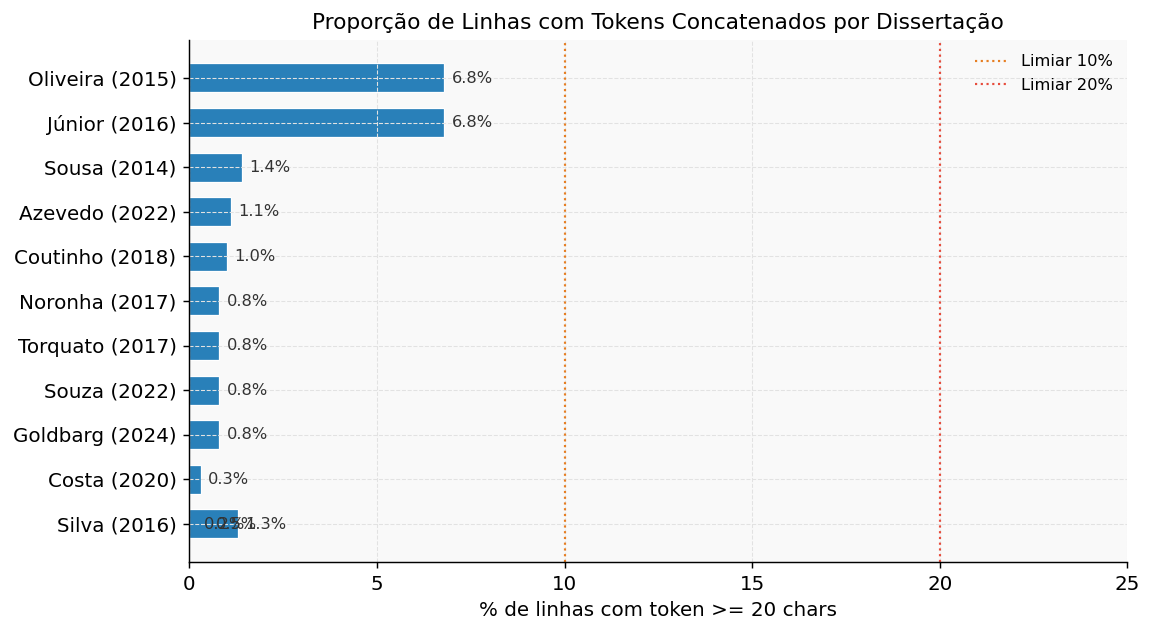

Figura salva: ../figures/01_corpus_exploration/05_diagnostico_concatenacao.png


In [78]:
# ── Visualização do diagnóstico de concatenação ──────────────────────────────
df_diag = diag.sort_values("pct_concat", ascending=True).copy()
df_diag["label"] = df_diag.apply(
    lambda r: f"{r['sobrenome']} ({int(r['ano'])})", axis=1
)

cores_diag = [
    "#e74c3c" if v > 20 else ("#e67e22" if v > 10 else "#2980b9")
    for v in df_diag["pct_concat"]
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    df_diag["label"], df_diag["pct_concat"],
    color=cores_diag, edgecolor="white", linewidth=0.7, height=0.65
)
ax.axvline(10, color="#e67e22", linestyle=":", linewidth=1.2, label="Limiar 10%")
ax.axvline(20, color="#e74c3c", linestyle=":", linewidth=1.2, label="Limiar 20%")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{w:.1f}%", va="center", fontsize=9, color="#333")

ax.set_title("Proporção de Linhas com Tokens Concatenados por Dissertação")
ax.set_xlabel("% de linhas com token >= 20 chars")
ax.set_xlim(0, max(df_diag["pct_concat"].max() + 4, 25))
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
fig_path = DIR_FIGURES / "05_diagnostico_concatenacao.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva: {fig_path}")

<h2 style="font-family: Georgia, serif; color: #2c3e50; border-bottom: 1px solid #dce0e4; padding-bottom: 6px; margin-top: 30px;">
  7. Síntese e Exportação
</h2>
<p style="font-family: sans-serif; font-size: 0.9em; color: #555; line-height: 1.65; max-width: 820px;">
  Tabela consolidada com todas as métricas coletadas neste notebook, exportada para
  <code>results/01_corpus_exploration/corpus_summary.csv</code>. Esta tabela é o ponto de partida do Notebook 02
  e pode ser referenciada diretamente no relatório.
</p>

In [79]:
cols_export = [
    "tese_id", "autor", "titulo", "ano", "programa",
    "agencia", "orientador_ou_coorientador",
    "n_paginas", "n_pag_texto", "n_linhas", "n_palavras",
]
cols_export = [c for c in cols_export if c in meta.columns]

summary = meta[cols_export].sort_values("ano").reset_index(drop=True)

out_csv = DIR_RESULTS / "corpus_summary.csv"
summary.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"Tabela exportada: {out_csv}\n")

pd.set_option("display.max_colwidth", 48)
cols_display = ["tese_id", "autor", "ano", "n_paginas", "n_pag_texto", "n_linhas", "n_palavras"]
summary[[c for c in cols_display if c in summary.columns]]

Tabela exportada: ../results/01_corpus_exploration/corpus_summary.csv



,tese_id,autor,ano,n_paginas,n_pag_texto,n_linhas,n_palavras
0,19,Tiago Fernando Barbosa de Sousa,2014,0,80,993,13274
1,18,Átila Varela Ferreira Medeiros de Oliveira,2015,0,63,880,9971
2,14,Sérgio Natan Silva,2016,0,75,1202,15764
3,15,Caroline Albuquerque Dantas Silva,2016,0,81,1457,19435
4,16,Lucileide Medeiros Dantas da Silva,2016,0,65,1039,14436
5,17,Carlos Eduardo de Barros Santos Júnior,2016,0,66,1363,18224
6,12,Matheus Fernandes Torquato,2017,0,66,1229,16592
7,13,Daniel Holanda Noronha,2017,0,66,1229,16592
8,11,MARIA GRACIELLY FERNANDES COUTINHO,2018,0,63,1233,16331
9,09,EMANOEL LUCAS RODRIGUES COSTA,2020,0,90,1880,26597


In [80]:
# ── Painel de totais ─────────────────────────────────────────────────────────
sep = "=" * 52
print(sep)
print("  RESUMO DO CORPUS")
print(sep)
print(f"  Dissertações             : {len(meta):>8}")
print(f"  PDFs localizados         : {meta['pdf_found'].sum():>8}")
print(f"  Período                  : {int(meta['ano'].min())} – {int(meta['ano'].max())}")
print(f"  Total de páginas         : {meta['n_paginas'].sum():>8,.0f}")
print(f"  Média de páginas / tese  : {meta['n_paginas'].mean():>8.1f}")
print(f"  Total de palavras        : {meta['n_palavras'].sum():>8,.0f}")
print(f"  Média de palavras / tese : {meta['n_palavras'].mean():>8,.0f}")
print(sep)
print(f"  Saídas geradas:")
print(f"    data/extracted_text/   {len(list(DIR_TEXT.glob('*.json')))} arquivos JSON")
print(f"    figures/01_corpus_exploration/  {len(list(DIR_FIGURES.glob('*.png')))} figuras PNG")
print(f"    results/01_corpus_exploration/corpus_summary.csv")
print(sep)

  RESUMO DO CORPUS
  Dissertações             :       13
  PDFs localizados         :       13
  Período                  : 2014 – 2024
  Total de páginas         :        0
  Média de páginas / tese  :      0.0
  Total de palavras        :  234,273
  Média de palavras / tese :   18,021
  Saídas geradas:
    data/extracted_text/   13 arquivos JSON
    figures/01_corpus_exploration/  5 figuras PNG
    results/01_corpus_exploration/corpus_summary.csv


<h2 style="font-family: Georgia, serif; color: #2c3e50; border-bottom: 1px solid #dce0e4; padding-bottom: 6px; margin-top: 30px;">
  8. Observações Qualitativas
</h2>
<p style="font-family: sans-serif; font-size: 0.9em; color: #555; line-height: 1.65; max-width: 820px;">
  Esta célula deve ser preenchida <strong>manualmente</strong> após a execução completa do notebook,
  com base nas Seções 5 e 6. As observações registradas aqui informam as decisões de
  pré-processamento do Notebook 02.
</p>

<hr style="border: none; border-top: 1px solid #e8e8e8; margin: 14px 0;">

<h3 style="font-family: sans-serif; font-weight: 600; color: #34495e; font-size: 0.95em; margin-bottom: 4px;">
  Qualidade geral da extração
</h3>
<p style="font-family: sans-serif; font-size: 0.88em; color: #777; font-style: italic;">
  [ Preencher: o texto está legível na maioria das dissertações? Algum arquivo retornou
  extração vazia ou com menos de 500 linhas? ]
</p>

<h3 style="font-family: sans-serif; font-weight: 600; color: #34495e; font-size: 0.95em; margin-bottom: 4px;">
  Concatenação de palavras
</h3>
<p style="font-family: sans-serif; font-size: 0.88em; color: #777; font-style: italic;">
  [ Preencher: quais dissertações apresentaram % alto de concatenação (> 20%)?
  Isso impacta o NER e deve ser tratado em <code>src/02_extraction/clean_text.py</code>. ]
</p>

<h3 style="font-family: sans-serif; font-weight: 600; color: #34495e; font-size: 0.95em; margin-bottom: 4px;">
  Idioma
</h3>
<p style="font-family: sans-serif; font-size: 0.88em; color: #777; font-style: italic;">
  [ Preencher: todas as dissertações estão em português? A dissertação 11 (Coutinho, 2018)
  tem título em inglês — verificar idioma do corpo do texto. Isso afeta a escolha do
  modelo spaCy no Notebook 02: <code>pt_core_news_lg</code> vs. <code>en_core_web_lg</code>. ]
</p>

<h3 style="font-family: sans-serif; font-weight: 600; color: #34495e; font-size: 0.95em; margin-bottom: 4px;">
  Próximos passos
</h3>
<ul style="font-family: sans-serif; font-size: 0.88em; color: #555; line-height: 1.85; max-width: 780px;">
  <li>Executar o <strong>Notebook 02</strong> para aplicação do NER sobre os textos em <code>data/extracted_text/</code>.</li>
  <li>Se o percentual de concatenação for crítico em alguma dissertação, aplicar normalização
      adicional antes do NER.</li>
  <li>Para dissertações em inglês, usar o modelo <code>en_core_web_lg</code> no lugar de
      <code>pt_core_news_lg</code> durante a etapa de NER.</li>
</ul>